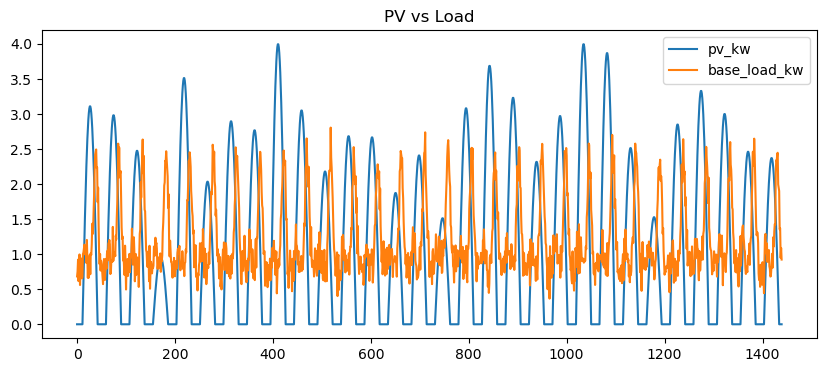

In [294]:
import pandas as pd

df = pd.read_csv("caseA_smart_home_30min_summer.csv")

df.head(1440)

dt= 0.5 #hours
df['pv_kwh'] = df['pv_kw'] * dt
df['load_kwh'] = df['base_load_kw'] * dt

import matplotlib.pyplot as plt

df[['pv_kw', 'base_load_kw']].plot(figsize=(10,4))
plt.title("PV vs Load")
plt.show()

# Extract key variables

pv = df['pv_kwh'].values
load = df['load_kwh'].values
price_import = df['import_tariff_gbp_per_kwh'].values
price_export = df['export_price_gbp_per_kwh'].values

In [295]:
# Battery parameters
battery_capacity = 5.0      # kWh
soc_init = 2.5               # kWh
soc_min = 0.5               # kWh
soc_max = battery_capacity   # kWh

p_charge_max = 2.5           # kW
p_discharge_max = 2.5      # kW

eta_charge = 0.95
eta_discharge = 0.95

# Convert power limits to energy per timestep
e_charge_max = p_charge_max * dt
e_discharge_max = p_discharge_max * dt


In [296]:
import numpy as np

n = len(df)

soc = np.zeros(n + 1)
soc[0] = soc_init

charge = np.zeros(n)         # kWh charged into battery each timestep
discharge = np.zeros(n)      # kWh discharged from battery each timestep
grid_import = np.zeros(n)    # kWh imported from grid
grid_export = np.zeros(n)    # kWh exported to grid
pv_to_load = np.zeros(n)     # kWh from PV directly to load

In [297]:
for t in range(n):
    pv_available = pv[t]
    load_needed = load[t]

    # 1. PV serves load first
    pv_to_load[t] = min(pv_available, load_needed)
    pv_surplus = pv_available - pv_to_load[t]
    load_remaining = load_needed - pv_to_load[t]

    # 2. Charge battery with surplus PV
    battery_room = soc_max - soc[t]
    max_charge_possible = min(e_charge_max, battery_room / eta_charge)
    charge[t] = min(pv_surplus, max_charge_possible)

    soc_after_charge = soc[t] + eta_charge * charge[t]
    pv_surplus_after_charge = pv_surplus - charge[t]

    # 3. Export any remaining PV surplus
    grid_export[t] = pv_surplus_after_charge
    
    # 4. On the last day, protect enough SOC to end at soc_init
    if t >= n - 48:
        effective_soc_min = soc_init
    else:
        effective_soc_min = soc_min

    battery_available = soc_after_charge - effective_soc_min
    battery_available = max(battery_available, 0)
    
    max_discharge_possible = min(e_discharge_max, battery_available * eta_discharge)
    discharge[t] = min(load_remaining, max_discharge_possible)

    soc[t + 1] = soc_after_charge - discharge[t] / eta_discharge

    # 5. Import any remaining unmet load
    load_after_discharge = load_remaining - discharge[t]
    grid_import[t] = load_after_discharge
    
soc_shortfall = soc_init - soc[-1]
if soc_shortfall > 1e-6:
    avg_tariff = price_import.mean()
    soc_penalty = soc_shortfall * avg_tariff / eta_charge
    print(f'SOC shortfall: {soc_shortfall:.4f} kWh → penalty: £{soc_penalty:.4f}')
else:
    soc_penalty = 0.0
    print(f'No SOC shortfall (final SOC = {soc[-1]:.4f})')

No SOC shortfall (final SOC = 2.5000)


In [298]:
print("Final SOC:", soc[-1])
print("Initial SOC:", soc_init)
print("Total grid import (kWh):", grid_import.sum())
print("Total grid export (kWh):", grid_export.sum())


Final SOC: 2.5
Initial SOC: 2.5
Total grid import (kWh): 298.312125875
Total grid export (kWh): 240.3209932132964


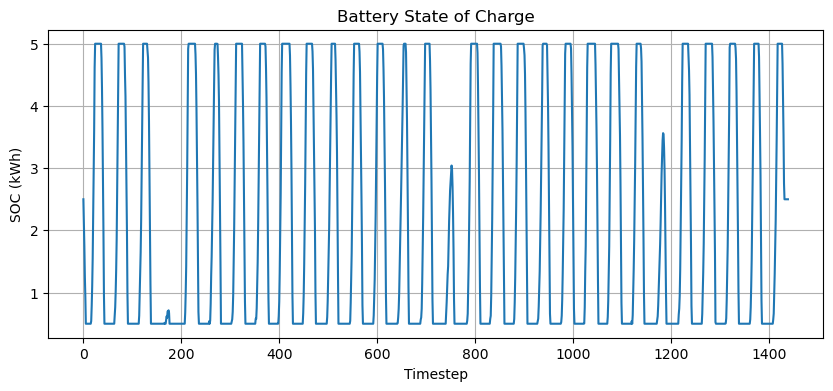

In [299]:
plt.figure(figsize=(10,4))
plt.plot(soc[:-1])
plt.title("Battery State of Charge")
plt.ylabel("SOC (kWh)")
plt.xlabel("Timestep")
plt.grid(True)
plt.show()

In [300]:
print("SOC min:", soc.min())
print("SOC max:", soc.max())

print("Any negative grid import?", (grid_import < -1e-9).any())
print("Any negative grid export?", (grid_export < -1e-9).any())
print("Any negative charge?", (charge < -1e-9).any())
print("Any negative discharge?", (discharge < -1e-9).any())

SOC min: 0.4999999999999999
SOC max: 5.0
Any negative grid import? False
Any negative grid export? False
Any negative charge? False
Any negative discharge? False


In [301]:
balance_error = pv - (pv_to_load + charge + grid_export)
load_error = load - (pv_to_load + discharge + grid_import)

print("Max PV-side balance error:", abs(balance_error).max())
print("Max load-side balance error:", abs(load_error).max())


Max PV-side balance error: 2.220446049250313e-16
Max load-side balance error: 1.1102230246251565e-16


In [302]:
# Check: no simultaneous charge and discharge
simul = ((charge > 1e-10) & (discharge > 1e-10)).sum()
print("Simultaneous ch/dis violations:", simul)

# Check: SOC dynamics (recompute independently)
soc_check = np.zeros(n + 1)
soc_check[0] = soc_init
for t in range(n):
    soc_check[t+1] = soc_check[t] + eta_charge * charge[t] - discharge[t] / eta_discharge
print("SOC recompute drift:", np.abs(soc_check - soc).max())

# Check: global energy conservation
total_in = pv.sum() + grid_import.sum()
total_out = load.sum() + grid_export.sum()
delta_soc = soc[-1] - soc[0]
losses = charge.sum() * (1 - eta_charge) + discharge.sum() * (1/eta_discharge - 1)
cons_err = abs(total_in - total_out - delta_soc - losses)
print("Conservation error:", cons_err, "kWh")

# Unit check (worked example, step t=14)
t_ex = 14
print(f"\nUnit check (t={t_ex}):")
print(f"  {grid_import[t_ex]/dt:.4f} kW × {dt} h = {grid_import[t_ex]:.4f} kWh")
print(f"  {grid_import[t_ex]:.4f} kWh × {price_import[t_ex]:.4f} £/kWh = £{grid_import[t_ex]*price_import[t_ex]:.6f}")

Simultaneous ch/dis violations: 0
SOC recompute drift: 0.0
Conservation error: 2.2737367544323206e-13 kWh

Unit check (t=14):
  0.1459 kW × 0.5 h = 0.0730 kWh
  0.0730 kWh × 0.1146 £/kWh = £0.008360


In [303]:
import_cost = np.sum(grid_import * price_import)
export_revenue = np.sum(grid_export * price_export)
net_cost = import_cost - export_revenue

print("Import cost (£):", import_cost)
print("Export revenue (£):", export_revenue)
print("Net cost (£):", net_cost)

Import cost (£): 41.01643253282501
Export revenue (£): 12.014461329736843
Net cost (£): 29.001971203088164


In [304]:
baseline_grid_import = np.maximum(load - pv, 0)
baseline_grid_export = np.maximum(pv - load, 0)

baseline_import_cost = np.sum(baseline_grid_import * price_import)
baseline_export_revenue = np.sum(baseline_grid_export * price_export)
baseline_net_cost = baseline_import_cost - baseline_export_revenue

print("Baseline import cost (£):", baseline_import_cost)
print("Baseline export revenue (£):", baseline_export_revenue)
print("Baseline net cost (£):", baseline_net_cost)

Baseline import cost (£): 78.958279825
Baseline export revenue (£): 18.70480698
Baseline net cost (£): 60.253472845000005


In [305]:
print("Battery case net cost (£):", net_cost)
print("Savings vs baseline (£):", baseline_net_cost - net_cost)

Battery case net cost (£): 29.001971203088164
Savings vs baseline (£): 31.25150164191184


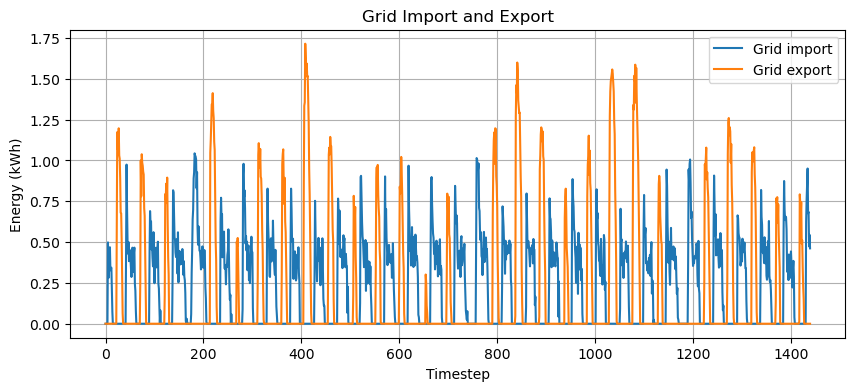

In [306]:
plt.figure(figsize=(10,4))
plt.plot(grid_import, label="Grid import")
plt.plot(grid_export, label="Grid export")
plt.title("Grid Import and Export")
plt.xlabel("Timestep")
plt.ylabel("Energy (kWh)")
plt.legend()
plt.grid(True)
plt.show()

In [307]:
pv_total = pv.sum()
load_total = load.sum()

pv_used_locally = pv_to_load.sum() + charge.sum()
self_consumption_ratio = pv_used_locally / pv_total

print("Total PV generation (kWh):", pv_total)
print("Total load (kWh):", load_total)
print("PV used locally (kWh):", pv_used_locally)
print("Self-consumption ratio:", self_consumption_ratio)


Total PV generation (kWh): 812.4226
Total load (kWh): 857.3335999999999
PV used locally (kWh): 572.1016067867037
Self-consumption ratio: 0.7041921369330489


In [308]:
self_sufficiency_ratio = 1 - grid_import.sum() / load_total
print("Self-sufficiency ratio:", self_sufficiency_ratio)


Self-sufficiency ratio: 0.6520466177051734


In [309]:
# Policy 2: tariff-aware discharge

price_threshold = 0.20  # £/kWh — sits between the 12p and 34p clusters

soc2 = np.zeros(n + 1)
soc2[0] = soc_init

charge2 = np.zeros(n)
discharge2 = np.zeros(n)
grid_import2 = np.zeros(n)
grid_export2 = np.zeros(n)
pv_to_load2 = np.zeros(n)

for t in range(n):
    pv_available = pv[t]
    load_needed = load[t]

    if t >= n - 48:
        effective_soc_min = soc_init
    else:
        effective_soc_min = soc_min

    # 1. PV serves load first
    pv_to_load2[t] = min(pv_available, load_needed)
    pv_surplus = pv_available - pv_to_load2[t]
    load_remaining = load_needed - pv_to_load2[t]

    # 2. Charge battery from surplus PV
    battery_room = soc_max - soc2[t]
    max_charge_possible = min(e_charge_max, battery_room / eta_charge)
    charge2[t] = min(pv_surplus, max_charge_possible)

    soc_after_charge = soc2[t] + eta_charge * charge2[t]
    pv_surplus_after_charge = pv_surplus - charge2[t]

    # 3. Export remaining surplus
    grid_export2[t] = pv_surplus_after_charge

    # 4. Only discharge battery when tariff is high
    if price_import[t] >= price_threshold:
        battery_available = soc_after_charge - effective_soc_min
        battery_available = max(battery_available, 0)
        max_discharge_possible = min(e_discharge_max, battery_available * eta_discharge)
        discharge2[t] = min(load_remaining, max_discharge_possible)
    else:
        discharge2[t] = 0.0

    soc2[t + 1] = soc_after_charge - discharge2[t] / eta_discharge

    # 5. Import remaining load
    load_after_discharge = load_remaining - discharge2[t]
    grid_import2[t] = load_after_discharge
    

soc_shortfall2 = soc_init - soc2[-1]
if soc_shortfall2 > 1e-6:
    avg_tariff = price_import.mean()
    soc_penalty2 = soc_shortfall2 * avg_tariff / eta_charge
    print(f'SOC shortfall2: {soc_shortfall2:.4f} kWh → penalty: £{soc_penalty2:.4f}')
else:
    soc_penalty2 = 0.0
    print(f'No SOC shortfall (final SOC = {soc2[-1]:.4f})')

No SOC shortfall (final SOC = 2.5000)


In [310]:
import_cost2 = np.sum(grid_import2 * price_import)
export_revenue2 = np.sum(grid_export2 * price_export)
net_cost2 = import_cost2 - export_revenue2

print("Policy 1 net cost (£):", net_cost)
print("Policy 2 net cost (£):", net_cost2)
print("Price threshold:", price_threshold)

Policy 1 net cost (£): 29.001971203088164
Policy 2 net cost (£): 29.895111254247542
Price threshold: 0.2


In [311]:
print("Policy 1 net cost (£):", net_cost)
print("Policy 2 net cost (£):", net_cost2)
print("Difference (£):", net_cost2 - net_cost)
print("Policy 1 better?", net_cost < net_cost2)

Policy 1 net cost (£): 29.001971203088164
Policy 2 net cost (£): 29.895111254247542
Difference (£): 0.8931400511593779
Policy 1 better? True


In [312]:
print("Policy 1 grid import (kWh):", grid_import.sum())
print("Policy 2 grid import (kWh):", grid_import2.sum())

print("Policy 1 grid export (kWh):", grid_export.sum())
print("Policy 2 grid export (kWh):", grid_export2.sum())

Policy 1 grid import (kWh): 298.312125875
Policy 2 grid import (kWh): 312.9691215
Policy 1 grid export (kWh): 240.3209932132964
Policy 2 grid export (kWh): 256.56143157894735


In [313]:
# End-of-horizon SOC penalties
avg_tariff = price_import.mean()

shortfall1 = max(0, soc_init - soc[-1])
penalty1 = shortfall1 * avg_tariff / eta_charge if shortfall1 > 1e-6 else 0

shortfall2 = max(0, soc_init - soc2[-1])
penalty2 = shortfall2 * avg_tariff / eta_charge if shortfall2 > 1e-6 else 0

adjusted_cost1 = net_cost + penalty1
adjusted_cost2 = net_cost2 + penalty2

print("--- End-of-horizon adjustment ---")
print(f"Policy 1: shortfall = {shortfall1:.4f} kWh, penalty = £{penalty1:.4f}")
print(f"Policy 2: shortfall = {shortfall2:.4f} kWh, penalty = £{penalty2:.4f}")
print(f"Policy 1 adjusted cost: £{adjusted_cost1:.2f}")
print(f"Policy 2 adjusted cost: £{adjusted_cost2:.2f}")
print(f"Baseline:               £{baseline_net_cost:.2f}")

--- End-of-horizon adjustment ---
Policy 1: shortfall = 0.0000 kWh, penalty = £0.0000
Policy 2: shortfall = 0.0000 kWh, penalty = £0.0000
Policy 1 adjusted cost: £29.00
Policy 2 adjusted cost: £29.90
Baseline:               £60.25


In [314]:

summary = pd.DataFrame({
    "Case": ["Baseline", "Policy 1", "Policy 2"],
    
    "Import cost (£)": [baseline_import_cost, import_cost, import_cost2],
    "Export revenue (£)": [baseline_export_revenue, export_revenue, export_revenue2],
    "Net cost (£)": [baseline_net_cost, net_cost, net_cost2],
    
    "Grid import (kWh)": [baseline_grid_import.sum(), grid_import.sum(), grid_import2.sum()],
    "Grid export (kWh)": [baseline_grid_export.sum(), grid_export.sum(), grid_export2.sum()],
    
    "Final SOC (kWh)": [np.nan, soc[-1], soc2[-1]],
    "Initial SOC (kWh)": [np.nan, soc_init, soc_init]
})

summary

,Case,Import cost (£),Export revenue (£),Net cost (£),Grid import (kWh),Grid export (kWh),Final SOC (kWh),Initial SOC (kWh)
0,Baseline,78.958280,18.704807,60.253473,419.387200,374.476200,NaN,NaN
1,Policy 1,41.016433,12.014461,29.001971,298.312126,240.320993,2.5,2.5
2,Policy 2,42.711910,12.816799,29.895111,312.969122,256.561432,2.5,2.5
